In [ ]:
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
import pandas as pd
import mne

df = pd.read_excel(r"C:\Users\Admin\Documents\Thesis\start-end.xlsx")

df.columns = df.columns.str.strip()

In [ ]:
df = df.rename(columns={
    "Unnamed: 0": "event_type",
    "Line (Excel file)": "file_id"
})

In [ ]:
df["event_type"] = df["event_type"].ffill()

In [ ]:
#clean data
df = df.dropna(subset=["file_id"])

df["file_id"] = df["file_id"].astype(int).astype(str)
df["event_type"] = df["event_type"].astype(str).str.strip()

In [ ]:
df = df[df["event_type"].isin(["ESz", "IED"])]

In [ ]:
def time_to_seconds(t):
    if pd.isna(t):
        return None
    
    t = str(t).replace("’", ":").replace("”", "")
    
    try:
        m, s = t.split(":")
        return int(m)*60 + int(s)
    except:
        return None

df["start_sec"] = df["Start"].apply(time_to_seconds)
df["end_sec"] = df["end"].apply(time_to_seconds)

df = df.dropna(subset=["start_sec", "end_sec"])

In [ ]:
print("Total seizure annotations:", len(df))

Total seizure annotations: 344


In [ ]:
print(df.head(10))

  event_type file_id  Start     end  start_sec  end_sec
0        ESz      81  5’05”  10’07”        305    607.0
1        ESz     308  5’43”   8’07”        343    487.0
2        ESz     311  9’33”  11’07”        573    667.0
3        ESz     357  9’27”  11’02”        567    662.0
4        IED      83  6’06”   6’10”        366    370.0
5        IED      83  6’50”   6’54”        410    414.0
6        IED      83  7’17”   7’21”        437    441.0
7        IED      83  7’35”   7’38”        455    458.0
8        IED      83  7’47”   7’51”        467    471.0
9        IED      83  8’08”   8’10”        488    490.0


In [ ]:
sum(df["end_sec"] - df["start_sec"])

1679.0

In [ ]:
import os

def get_intervals(file_path, df):
    
    file_name = os.path.basename(file_path)
    file_id = file_name.split("_")[0]   
    
    rows = df[df["file_id"] == file_id]
    
    intervals = [(r["start_sec"], r["end_sec"]) for _, r in rows.iterrows()]
    
    return intervals

In [ ]:
import glob

edf_files = glob.glob(r"C:\Users\Admin\Documents\Thesis\data\raw\*.edf")

print("Total EDF files:", len(edf_files))
print(edf_files[:5])  # preview first 5 file paths

Total EDF files: 351
['C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\100_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\101_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\102_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\103_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\104_byte_anon.edf']


In [ ]:
test_file = edf_files[0]

intervals = get_intervals(test_file, df)

print("File:", test_file)
print("Intervals:", intervals)

File: C:\Users\Admin\Documents\Thesis\data\raw\100_byte_anon.edf
Intervals: []


In [ ]:
TARGET_CHANNELS = 16  

In [ ]:
def process_file(file_path, df, window_size=3):
    
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    
    samples = int(window_size * sfreq)
    step = samples   
    
    intervals = get_intervals(file_path, df)
    
    segments = []
    labels = []
    
    for start in range(0, data.shape[1] - samples, step):
        
        end = start + samples
        
        segment = data[:, start:end]

# Ensure correct length
        if segment.shape[1] < samples:
            continue

# SAME NUMBER OF CHANNELS
        if segment.shape[0] >= TARGET_CHANNELS:
            segment = segment[:TARGET_CHANNELS, :]
        else:
            continue
        
        start_time = start / sfreq
        end_time = end / sfreq
        
        label = 0
        
        for s_start, s_end in intervals:
            
            overlap = max(0, min(end_time, s_end) - max(start_time, s_start))
            
            if overlap > 0:
                label = 1
                break
        
        segments.append(segment)
        labels.append(label)
    
    return segments, labels

In [ ]:
all_segments = []
all_labels = []
file_ids = []

for file_path in edf_files:
    
    segs, labs = process_file(file_path, df, window_size=3)
    
    all_segments.extend(segs)
    all_labels.extend(labs)
    file_ids.extend([file_path]*len(labs))

Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\100_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 300499  =      0.000 ...   600.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\101_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 306499  =      0.000 ...   612.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\102_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 300999  =      0.000 ...   601.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\103_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 303499  =      0.000 ...   606.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\104_byte_anon.edf...
Setting channel info structure...
Creating raw.

In [ ]:
print("Total segments:", len(all_labels))
print("Seizure segments:", sum(all_labels))

Total segments: 91195
Seizure segments: 782


In [ ]:
def extract_features(seg):
    return np.std(seg, axis=1)   # only std

In [ ]:
# SPECTOGRAM
from scipy.signal import spectrogram

def extract_spectrogram(seg, sfreq):
    
    features = []
    
    for ch in seg:
        f, t, Sxx = spectrogram(ch, fs=sfreq)
        features.append(np.mean(Sxx))  
    
    return np.array(features)

In [ ]:
import numpy as np

feature_list = []
label_list = []
file_list = []

for seg, lab, fid in zip(all_segments, all_labels, file_ids):
    
    f = extract_features(seg)
    
 
    if f is None or len(f) == 0:
        continue
    
    feature_list.append(f)
    label_list.append(lab)
    file_list.append(fid)

In [ ]:
print("Number of features collected:", len(feature_list))

Number of features collected: 91195


In [ ]:
print("Total segments:", len(all_segments))
print("First segment shape:", all_segments[0].shape if len(all_segments)>0 else "None")

Total segments: 91195
First segment shape: (16, 1500)


In [ ]:
X = np.vstack([extract_features(seg) for seg in all_segments])
y = np.array(all_labels)
file_ids = np.array(file_ids)

In [ ]:
print("X shape:", X.shape)
print("Unique labels:", np.unique(y, return_counts=True))

X shape: (91195, 16)
Unique labels: (array([0, 1]), array([90413,   782]))


In [ ]:
# WINDOW-LEVEL SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [ ]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_prob_lr))
print("AUPRC:", average_precision_score(y_test, y_prob_lr))




Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     18083
           1       0.04      0.58      0.08       156

    accuracy                           0.88     18239
   macro avg       0.52      0.73      0.51     18239
weighted avg       0.99      0.88      0.93     18239

AUC: 0.8037188207652181
AUPRC: 0.0691436141971215


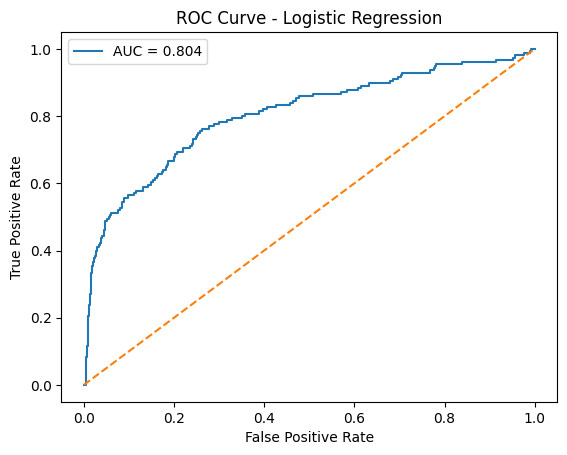

In [ ]:
# ROC CURVE

import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

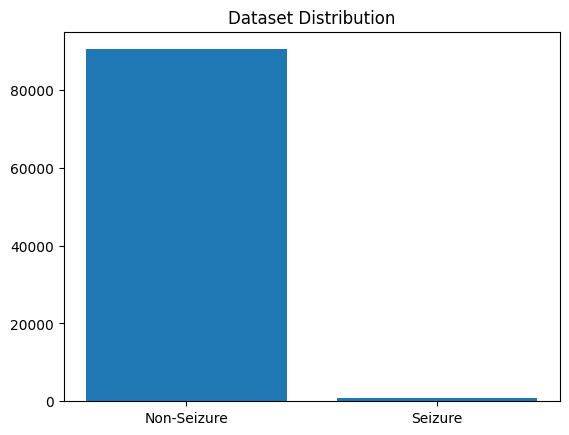

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["Non-Seizure", "Seizure"],
        [np.sum(y == 0), np.sum(y == 1)])

plt.title("Dataset Distribution")
plt.show()

In [ ]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]


threshold = 0.2

y_pred_custom = (y_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.99      0.01      0.02     18083
           1       0.01      0.99      0.02       156

    accuracy                           0.02     18239
   macro avg       0.50      0.50      0.02     18239
weighted avg       0.98      0.02      0.02     18239



In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("AUPRC:", average_precision_score(y_test, y_prob_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18083
           1       0.33      0.38      0.36       156

    accuracy                           0.99     18239
   macro avg       0.66      0.69      0.68     18239
weighted avg       0.99      0.99      0.99     18239

AUC: 0.7511698195074847
AUPRC: 0.33428049677983723


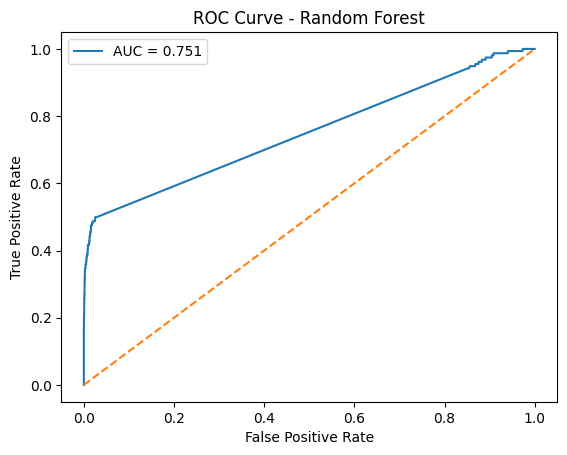

In [ ]:
# ROC CURVE

import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.show()

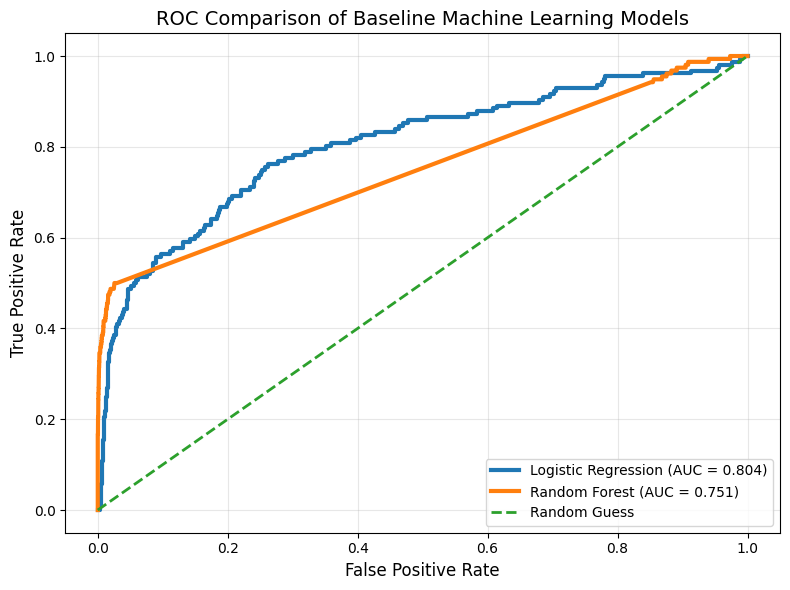

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC - Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# ROC - Random Forest
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=3,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})'
)

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title(
    'ROC Comparison of Baseline Machine Learning Models',
    fontsize=14
)

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'combined_ml_roc.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()